【Data Scaling(데이터 스케일링)】
- 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 피처 스케일링(feature scaling)이라고 한다.
- 피처(feature)=컬럼(column) 들마다 데이터의 값이 범위가 다 제각각이거나 단위가 다른 경우 데이터를 학습을 할때 0으로 수렴하거나 무한으로 발산할 수 있다.
  - 분석시에 변수들이 너무 스케일이 다를 경우  => 변수들의 단위 차이로 인해 숫자의 스케일이 크게 달라지는 경우
  - 신경망 학습시에 => 데이터셋의 값이 들쑥날쑥하거나, 매우 큰 경우에는 cost의 값이 발산하여 정상적인 학습이 이루어지지 않습니다.

- 이런 경우 데이터 스켈링을 통해 모든 피처들의 데이터 분포나 범위를 동일하게 조정해 줄 수 있다.
- Scaling 메서드는 scikit-learn의 preprocessing에서 제공한다.
- sklearn에서 제공하는 기본 Scaling 종류
   - StandardScaler : 평균이 0 분산이 1인 정규분포로 변환
   - MinMaxScaler :  0 ~ 1 사이의 실수로 변환, 타이타닉 생존자 예측(0 또는 1)과 같은 분류 문제보다는, 아파트 실거래가격 예측과 같은 회귀 문제를 해결할 때 더 적합한 스케일링 기법
   - RobustScaler : 중앙값이 0이고, IQR을 1로 변환, StandardScaler에 비해 이상치의 영향이 적어진다는 장점
   - MaxAbsScaler : 모든 피처들의 절댓값이 0과 1 사이에 놓이도록 변환, 극단적인 이상치에는 민감할 수 있으므로 꼭 이상치를 제거
   - Normalizer :  row를 기준으로 row(data point)마다 정규화를 진행, 한 행의 모든 features 사이에 유클리드 거리가 1이 되도록 데이터값을 변환, Normalizer를 사용하면 학습 속도도 빨라지고 과대적합 확률을 낮춤

In [ ]:
# '파이썬 라이브러리를 활용한 머신러닝'의 저자가 제공한 라이브러리
# !uv add mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 15.4 MB/s eta 0:00:00


In [1]:
import mglearn

c:\sk-encoa\data-collection-workspace\.venv\Lib\site-packages\mglearn\datasets.py:37: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [2]:
print(dir(mglearn))

['ReBl', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'cm2', 'cm3', 'datasets', 'discrete_scatter', 'plot_2d_separator', 'plot_agglomerative', 'plot_animal_tree', 'plot_cross_validation', 'plot_dbscan', 'plot_decomposition', 'plot_grid_search', 'plot_helpers', 'plot_improper_preprocessing', 'plot_interactive_tree', 'plot_kmeans', 'plot_kneighbors_regularization', 'plot_knn_classification', 'plot_knn_regression', 'plot_linear_regression', 'plot_linear_svc_regularization', 'plot_metrics', 'plot_nmf', 'plot_nn_graphs', 'plot_pca', 'plot_rbf_svm_parameters', 'plot_ridge', 'plot_scaling', 'plot_tree_nonmonotonous', 'plots', 'tools']


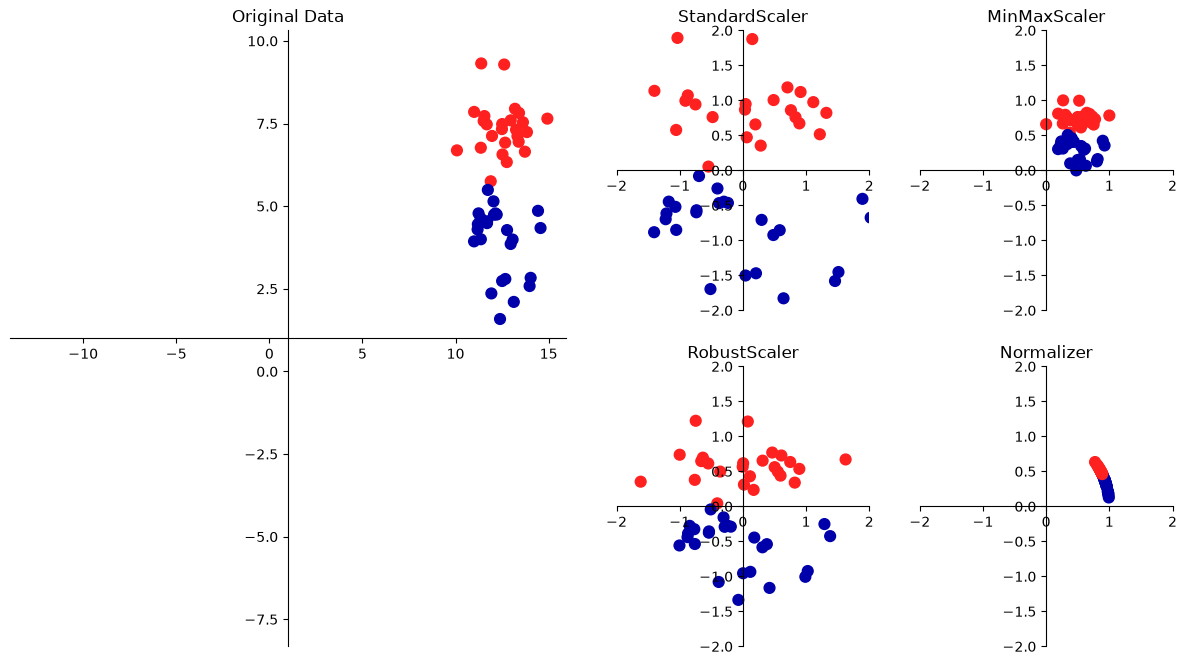

In [3]:
mglearn.plot_scaling.plot_scaling()

1. ## **`MaxAbsScaler`**

- 데이터의 **절대값이 1을 넘지 않도록** 스케일링
- 음수와 양수 값이 섞인 sparse 데이터에 적합
- 이상치에 민감하며, 분류보다는 회귀분석에서 유용


In [4]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform([[-1, 23], [0, 3], [1, -2]])
X_scaled


array([[-1.        ,  1.        ],
       [ 0.        ,  0.13043478],
       [ 1.        , -0.08695652]])

2. MinMaxScaler

- **최소-최대 정규화**: 데이터를 `[0, 1]` 범위로 변환
- 정규분포가 아닐때 사용
- 이상치에 민감
- 분류보다 회귀에 유용

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[0. , 0. ],
       [0.5, 0.5],
       [1. , 1. ]])

2.3 StandardScaler

- **Z-score 정규화**: 평균을 0, 표준편차를 1로 변환
- 이상치 영향을 받으므로 이상치가 없을때 사용
- 회귀보다는 분류분석에서 유용

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[-1.22474487, -1.22474487],
       [ 0.        ,  0.        ],
       [ 1.22474487,  1.22474487]])

2.4 Normalizer
- 각 행의 벡터 크기를 1로 정규화 (L1, L2, Max 노름 사용 가능)

In [8]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')
X_normalized = normalizer.transform([[1, 2], [3, 4]])
X_normalized


array([[0.4472136 , 0.89442719],
       [0.6       , 0.8       ]])

2.5 RobustScaler
- **중앙값과 IQR(사분위 범위) 기반 정규화**
- 이상치(Outlier)에 강한 정규화 방법

In [9]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# 예제 데이터
data = {
    'Income': [3000, 3200, 3400, 100000, 3600],  # 이상치 존재
    'Age': [25, 26, 27, 28, 29]
}
df = pd.DataFrame(data)
print(" 원본 데이터:\n", df)

# RobustScaler 객체 생성 및 적용
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df)

# 결과를 DataFrame으로 변환
df_scaled = pd.DataFrame(scaled_data, columns=['Income_scaled', 'Age_scaled'])
print("RobustScaler 결과:\n", df_scaled)

# 3          241.5         0.5  이상이 영향 작음

 원본 데이터:
    Income  Age
0    3000   25
1    3200   26
2    3400   27
3  100000   28
4    3600   29
RobustScaler 결과:
    Income_scaled  Age_scaled
0           -1.0        -1.0
1           -0.5        -0.5
2            0.0         0.0
3          241.5         0.5
4            0.5         1.0


| Feature 이름          | 설명      | 단위 |
| ------------------- | ------- | -- |
| `sepal length (cm)` | 꽃받침의 길이 | cm |
| `sepal width (cm)`  | 꽃받침의 너비 | cm |
| `petal length (cm)` | 꽃잎의 길이  | cm |
| `petal width (cm)`  | 꽃잎의 너비  | cm |


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler

In [11]:
iris = load_iris()
print(dir(iris))
print(iris.target)

iris = pd.DataFrame(iris.data, columns=iris.feature_names)

iris['Class'] = load_iris().target
iris['Class'] = iris['Class'].map({0:'Setosa', 1:'Versicolour', 2:'Virginica'})
iris.head()

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
from sklearn.model_selection import train_test_split


# X_관측값_훈련,X_관측값_테스트,y_정답_훈련,y_정답_테스트
# stratify=iris['Class'] : train, test을 분리할때 값의 비율을 유지하면서 분리하도록 설정한 파라미터이다.
# stratify을 설정해 주지 않으면 target의 컬럼으로 자동 설정된다.
X_train, X_test, y_train, y_test = train_test_split(iris.drop(columns='Class'), iris['Class'],   test_size=0.2) #  test_size=0.25.



In [13]:
X_train.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
32,5.2,4.1,1.5,0.1
62,6.0,2.2,4.0,1.0
31,5.4,3.4,1.5,0.4
124,6.7,3.3,5.7,2.1
111,6.4,2.7,5.3,1.9


In [14]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(120, 4) (120,)
(30, 4) (30,)


In [17]:
print(y_train.value_counts())

Class
Setosa         43
Versicolour    39
Virginica      38
Name: count, dtype: int64


In [18]:
print(y_test.value_counts())

Class
Virginica      12
Versicolour    11
Setosa          7
Name: count, dtype: int64


In [20]:
import seaborn as sns

In [21]:
print(type(y_train))
print(y_train.head())

<class 'pandas.Series'>
132      Virginica
50     Versicolour
8           Setosa
105      Virginica
104      Virginica
Name: Class, dtype: str


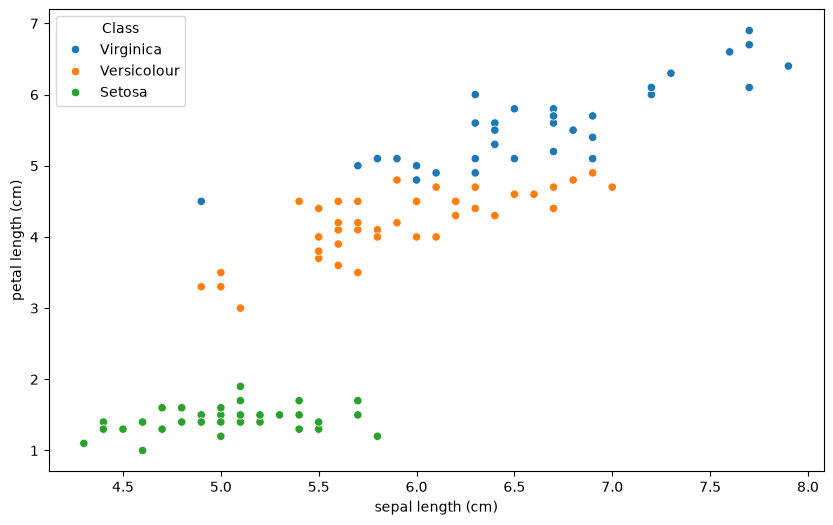

In [22]:
fig =sns.scatterplot(data=X_train, x=X_train.iloc[:,0], y=X_train.iloc[:,2], hue=y_train)
fig.figure.set_size_inches(10,6)

In [23]:
StdScaler = StandardScaler()

# Train데이터의 fitting과 스케일링
StdScaler.fit(X_train)  #fit()은 학습을 시키는 메소드이다.
X_train_sc = StdScaler.transform(X_train)  #transform() 실제로 학습시킨 것을 적용하는 메소드이다.

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

		(min, max)  (mean,std)
Train_scaled (-2.31, 2.93) ( -0.00, 1.00)


In [24]:
StdScaler2 = StandardScaler()
StdScaler2.fit_transform(X_train)

array([[ 0.71649937, -0.56588591,  1.0872757 ,  1.32838957],
       [ 1.4451428 ,  0.30750713,  0.57517027,  0.2848102 ],
       [-1.71231206, -0.34753765, -1.30254965, -1.28055885],
       [ 2.17378623, -0.12918939,  1.65628173,  1.19794215],
       [ 0.83793994, -0.12918939,  1.2010769 ,  1.32838957],
       [-0.2550252 , -0.12918939,  0.23376665,  0.15436278],
       [ 1.32370223,  0.08915887,  0.97347449,  1.19794215],
       [-1.71231206, -0.12918939, -1.35945025, -1.28055885],
       [ 0.5950588 ,  0.52585539,  1.31487811,  1.71973183],
       [ 0.5950588 ,  0.52585539,  0.57517027,  0.54570504],
       [-0.98366863, -2.31267198, -0.10763697, -0.23697948],
       [-0.98366863,  0.74420365, -1.24564904, -1.28055885],
       [-0.01214406, -0.78423416,  0.80277268,  0.93704731],
       [-0.01214406, -0.56588591,  0.80277268,  1.58928441],
       [-0.86222806, -1.22093068, -0.39213999, -0.10653206],
       [ 0.71649937, -0.34753765,  0.34756785,  0.15436278],
       [-1.46943092,  0.

In [25]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.716499,1.445143,-1.712312,2.173786,0.837940,-0.255025,1.323702,-1.712312,0.595059,0.595059,...,-0.376466,0.352178,1.202262,0.716499,0.595059,-1.105109,-1.469431,0.473618,0.837940,-0.133585
1,-0.565886,0.307507,-0.347538,-0.129189,-0.129189,-0.129189,0.089159,-0.129189,0.525855,0.525855,...,-1.220931,-0.565886,-0.565886,0.089159,-0.784234,-0.129189,1.180900,-0.347538,-0.565886,-1.220931
2,1.087276,0.575170,-1.302550,1.656282,1.201077,0.233767,0.973474,-1.359450,1.314878,0.575170,...,0.176866,0.575170,0.632071,1.030375,0.688971,-1.302550,-1.530152,0.347568,0.518270,0.745872
3,1.328390,0.284810,-1.280559,1.197942,1.328390,0.154363,1.197942,-1.280559,1.719732,0.545705,...,0.154363,0.023915,0.284810,0.806600,0.806600,-1.280559,-1.280559,0.154363,0.415258,1.067495


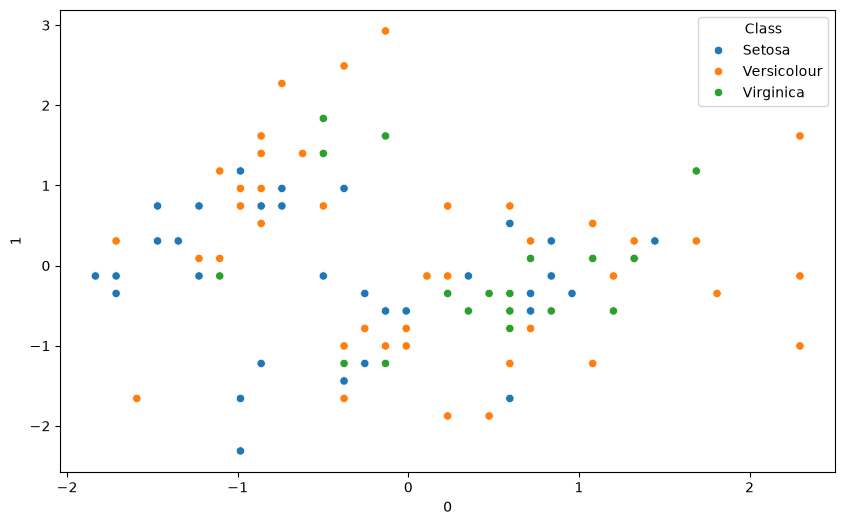

In [26]:
fig =sns.scatterplot(data=xt, x=xt.iloc[0,:], y=xt.iloc[1,], hue=y_train)
fig.figure.set_size_inches(10,6)

In [27]:
from sklearn.preprocessing import MinMaxScaler

MmScaler = MinMaxScaler()

# Train 데이터의 fitting과 스케일링
# fit()은 학습을 시키는 메소드이다.
MmScaler.fit(X_train)

#transform()은 실제로 학습시킨 것을 적용하는 메소드이다.
X_train_sc = MmScaler.transform(X_train)
print(X_train_sc.shape)

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

(120, 4)
		(min, max)  (mean,std)
Train_scaled (0.00, 1.00) ( 0.44, 0.26)


(480,)


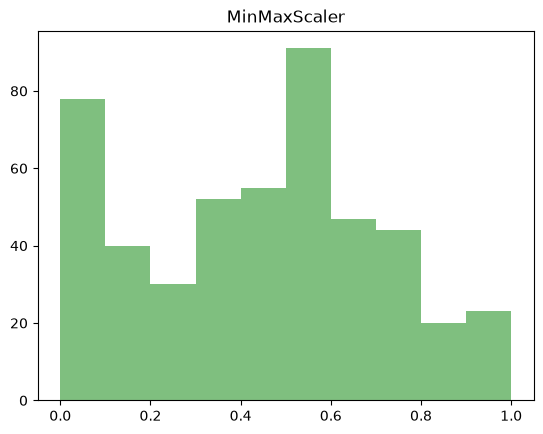

In [29]:
X_train_sc_flat = X_train_sc.flatten()
print(X_train_sc_flat.shape)
#print(X_train_sc_flat)
plt.hist(X_train_sc_flat, color='green', alpha=0.5)
plt.title('MinMaxScaler')
plt.show()

In [30]:
xt = pd.DataFrame(X_train_sc).T

In [31]:
xt.iloc[0, :].shape

(120,)

In [32]:
xt.iloc[1, :].shape

(120,)

In [33]:
xt.shape

(4, 120)

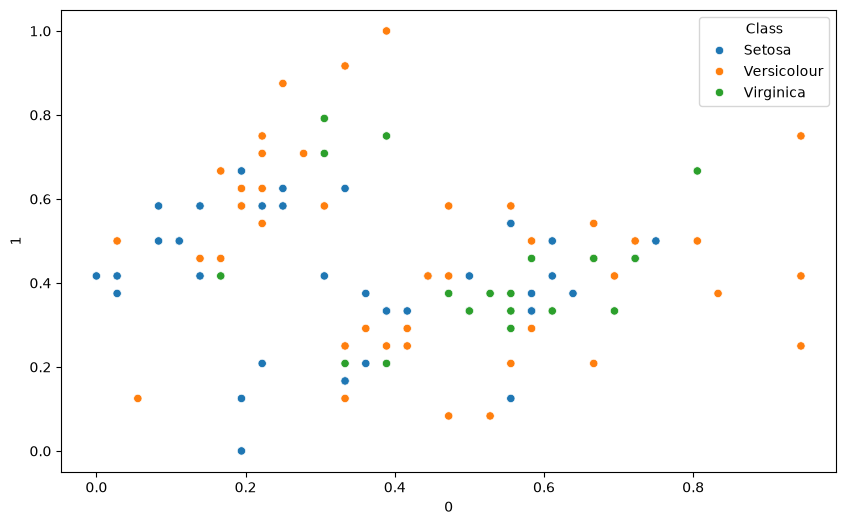

In [34]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [ ]:
from sklearn.preprocessing import MaxAbsScaler

MaScaler = MaxAbsScaler()   # 절대값이 1일 때

# Train 데이터의 fitting과 스케일링
MaScaler.fit(X_train)
X_train_sc = MaScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (0.04, 1.00) (0.61, 0.24)


In [36]:
X_train_sc.shape

(120, 4)

In [37]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.810127,0.886076,0.556962,0.962025,0.822785,0.708861,0.873418,0.556962,0.797468,0.797468,...,0.696203,0.772152,0.860759,0.810127,0.797468,0.620253,0.582278,0.784810,0.822785,0.721519
1,0.636364,0.727273,0.659091,0.681818,0.681818,0.681818,0.704545,0.681818,0.750000,0.750000,...,0.568182,0.636364,0.636364,0.704545,0.613636,0.681818,0.818182,0.659091,0.636364,0.568182
2,0.811594,0.681159,0.202899,0.956522,0.840580,0.594203,0.782609,0.188406,0.869565,0.681159,...,0.579710,0.681159,0.695652,0.797101,0.710145,0.202899,0.144928,0.623188,0.666667,0.724638
3,0.880000,0.560000,0.080000,0.840000,0.880000,0.520000,0.840000,0.080000,1.000000,0.640000,...,0.520000,0.480000,0.560000,0.720000,0.720000,0.080000,0.080000,0.520000,0.600000,0.800000


In [38]:
xt.shape

(4, 120)

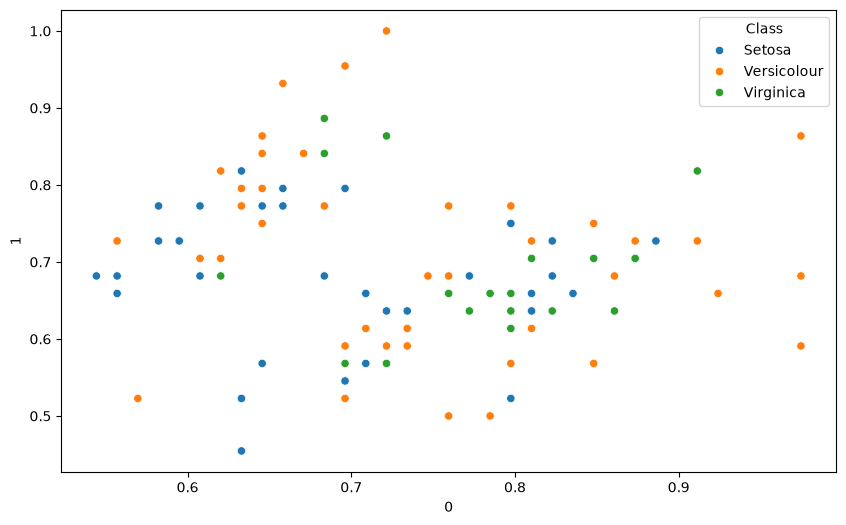

In [39]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [40]:
from sklearn.preprocessing import RobustScaler

RuScaler = RobustScaler()

# Train 데이터의 fitting과 스케일링
RuScaler.fit(X_train)
X_train_sc = RuScaler.transform(X_train)

print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (-1.67, 2.33) (-0.01, 0.62)


In [41]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.538462,1.000000,-1.000000,1.461538,0.615385,-0.076923,0.923077,-1.000000,0.461538,0.461538,...,-0.153846,0.307692,0.846154,0.538462,0.461538,-0.615385,-0.846154,0.384615,0.615385,0.000000
1,-0.333333,0.333333,-0.166667,0.000000,0.000000,0.000000,0.166667,0.000000,0.500000,0.500000,...,-0.833333,-0.333333,-0.333333,0.166667,-0.500000,0.000000,1.000000,-0.166667,-0.333333,-0.833333
2,0.388889,0.138889,-0.777778,0.666667,0.444444,-0.027778,0.333333,-0.805556,0.500000,0.138889,...,-0.055556,0.138889,0.166667,0.361111,0.194444,-0.777778,-0.888889,0.027778,0.111111,0.222222
3,0.600000,0.066667,-0.733333,0.533333,0.600000,0.000000,0.533333,-0.733333,0.800000,0.200000,...,0.000000,-0.066667,0.066667,0.333333,0.333333,-0.733333,-0.733333,0.000000,0.133333,0.466667


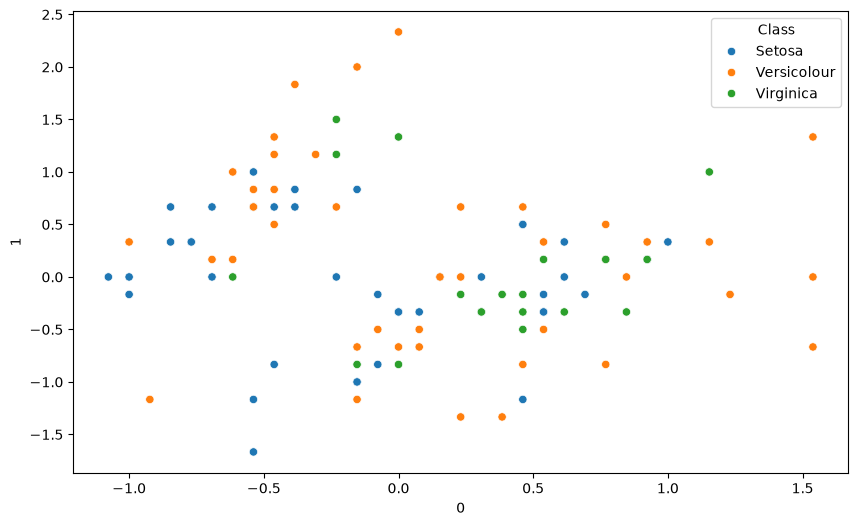

In [42]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [43]:
from sklearn.preprocessing import Normalizer

NoScaler = Normalizer()


# Train 데이터의 fitting과 스케일링
NoScaler.fit(X_train)
X_train_sc = NoScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))


		(min, max) (mean, std)
Train_scaled (0.01, 0.86) (0.44, 0.24)


In [44]:
xt = pd.DataFrame(X_train_sc.T)

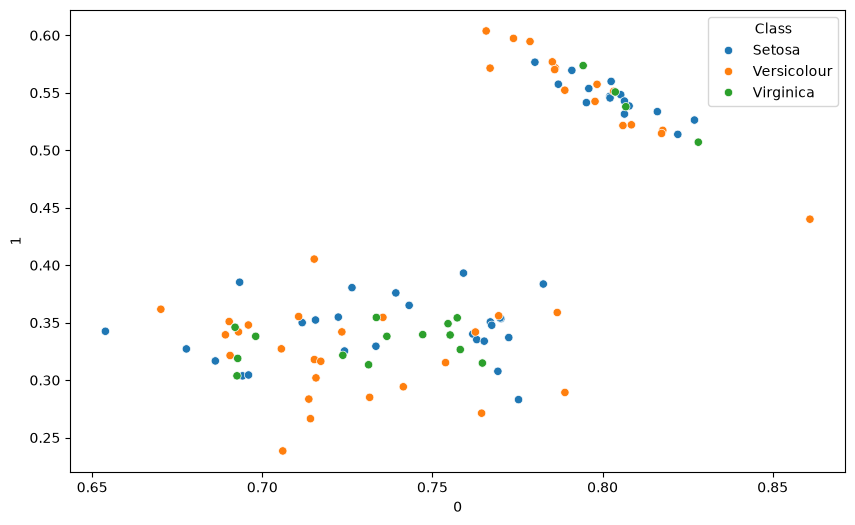

In [45]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)